## 1. Análisis Exploratiorio de Datos (EDA)
viviendas en California. 

Este análisis se centra en comprender la estructura y las características del conjunto de datos, así como en identificar patrones y relaciones entre las variables. Se utilizarán técnicas de visualización y estadísticas descriptivas para explorar los datos y obtener insights valiosos sobre los precios de las viviendas en California.

In [3]:
import pandas as pd
from IPython.display import display, Markdown

file_path = "/home/damaris/Escritorio/california_housing_prices/data/housing.csv"
data = pd.read_csv(file_path)


data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [5]:
# ocean_proximity es la única variable categórica
data["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [6]:
data.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [7]:
data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## 2. Identificación de datos atípicos

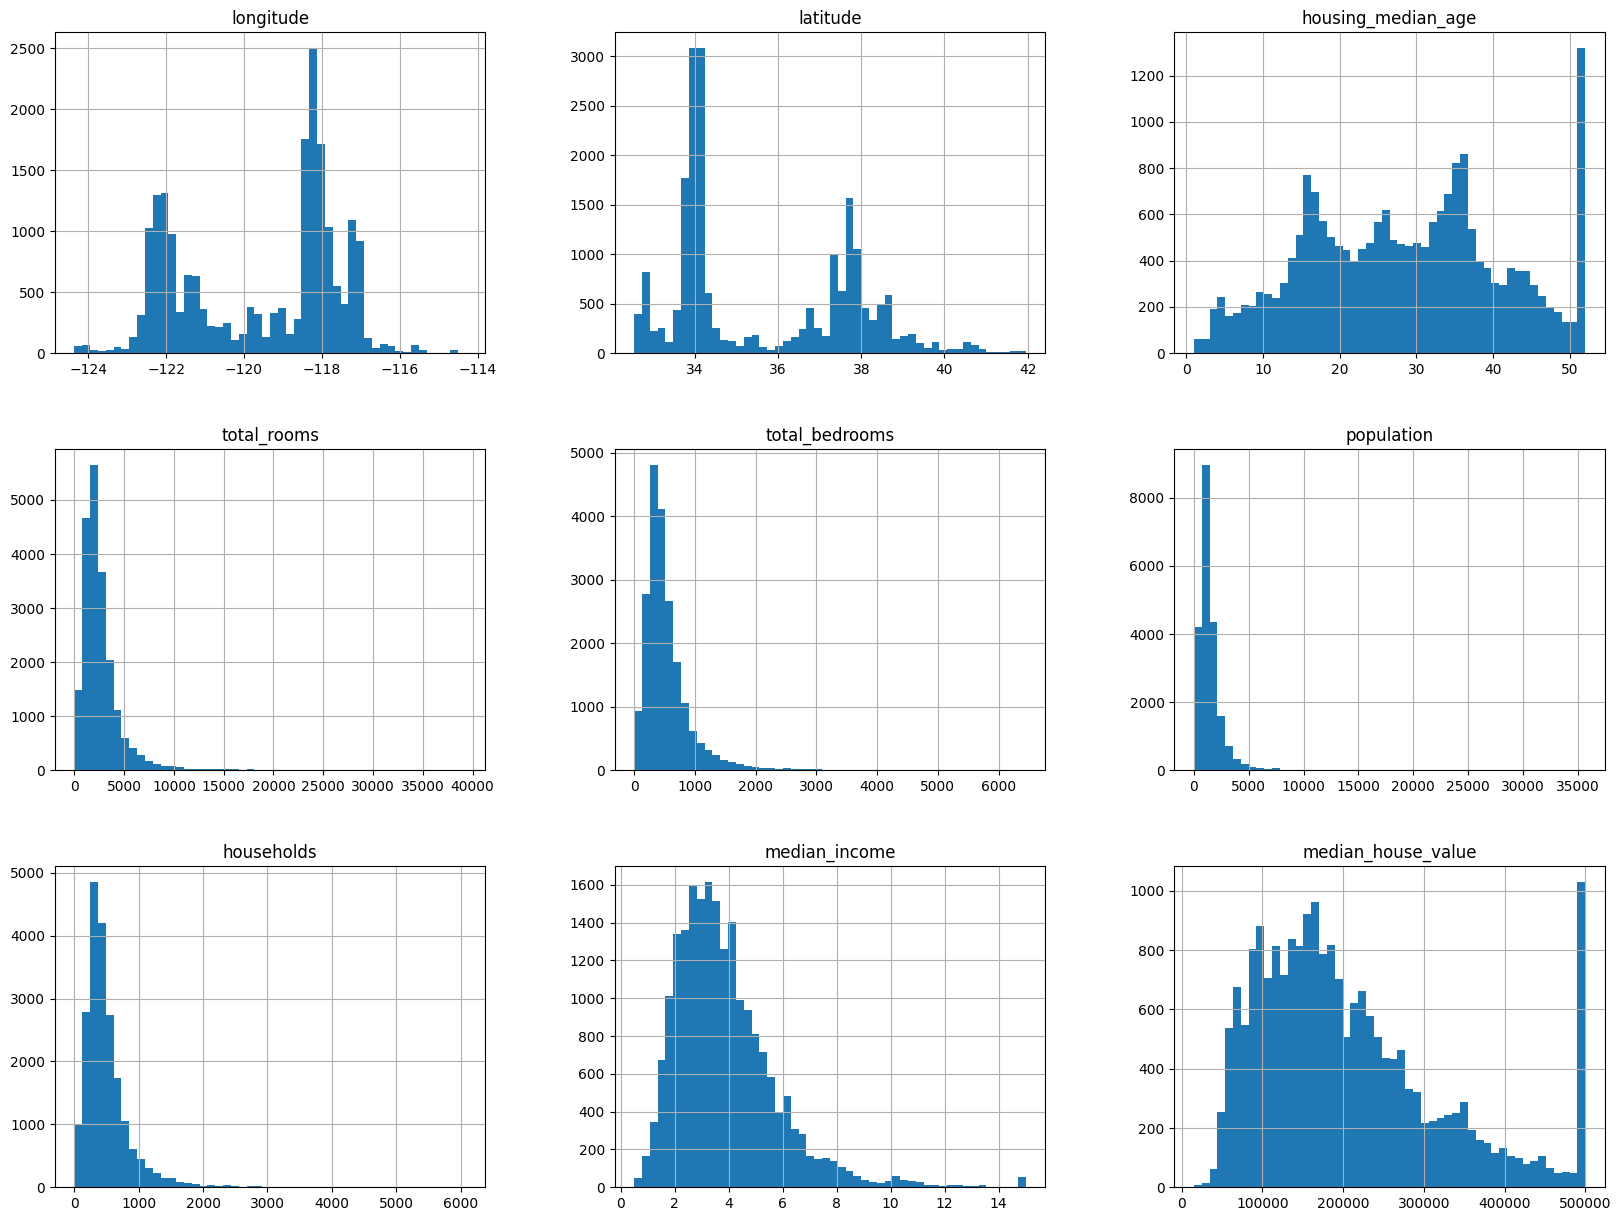

In [8]:
import matplotlib.pyplot as plt

data.hist(bins=50, figsize=(20, 15))
plt.show()

**Observaciones:**
1. median_income - Los números en x representan aproximádamente decenas de miles de dólares 3=$30.000 USD
2. housing_median_age - Está limitada en su valor máximo 52.000000
3. median_house_value - Está limitada a 500,000 USD.

- median_income tiene cola larga
- total_rooms, population tienen valores muy grandes

<Axes: >

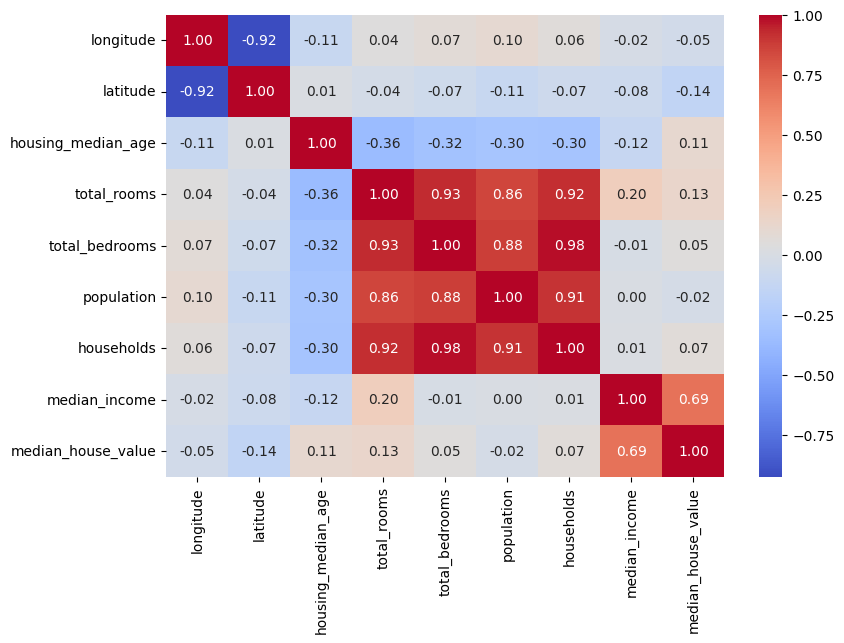

In [9]:
import seaborn as sns

corr_matrix = data.corr(numeric_only=True) # Matriz de correlación solo números

plt.figure(figsize=(9,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f") # Heatmap


In [10]:
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

**Observaciones:**
> El ingreso medio del área (median_income) es el factor más influyente en el precio de las viviendas, con una correlación de 0.688, lo que indica que las zonas con mayor ingreso suelen tener casas más caras.
- median_income → fuerte correlación con el precio
- total_rooms, population → correlación débil
- Ubicación influye indirectamente

--

| Variable           | Correlación | Interpretación                                                                                                                                   |
| ------------------ | ----------- | ------------------------------------------------------------------------------------------------------------------------------------------------ |
| **median_income**  | **0.688**   | Correlación positiva **fuerte**. A mayor ingreso medio del vecindario, mayor precio de las casas. Es la variable **más importante del dataset**. |
| total_rooms        | 0.134       | Correlación positiva **débil**. Más habitaciones puede implicar casas más grandes, pero no es un factor decisivo.                                |
| housing_median_age | 0.106       | Relación positiva débil. Casas más antiguas en algunas zonas pueden tener mayor valor, pero el efecto es pequeño.                                |
| households         | 0.065       | Relación muy débil. El número de hogares no explica bien el precio.                                                                              |
| total_bedrooms     | 0.049       | Correlación casi nula. El número de dormitorios por sí solo no determina el precio.                                                              |
| population         | -0.024      | Prácticamente **sin relación**.                                                                                                                  |
| longitude          | -0.046      | Relación negativa muy débil.                                                                                                                     |
| latitude           | -0.144      | Correlación negativa leve: algunas zonas más al norte tienden a ser un poco más baratas.                                                         |

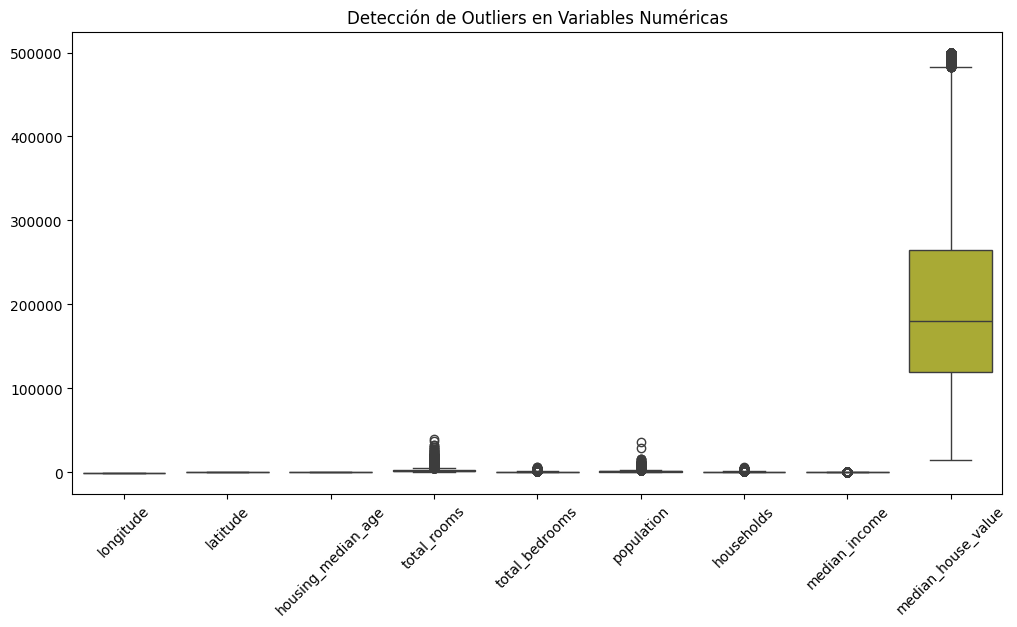

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = data.select_dtypes(include=['int64','float64']).columns

plt.figure(figsize=(12,6))
sns.boxplot(data=data[numeric_cols])
plt.xticks(rotation=45)
plt.title("Detección de Outliers en Variables Numéricas")
plt.show()

In [12]:
# numeric_cols = data.select_dtypes(include=['int64','float64']).columns
outlier_summary = []

for col in numeric_cols:
    
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = data[(data[col] < lower) | (data[col] > upper)]
    
    outlier_summary.append({
        "Variable": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Limite_inferior": lower,
        "Limite_superior": upper,
        "Num_Outliers": len(outliers),
        "Porcentaje_Outliers": round(len(outliers)/len(data)*100,2)
    })

outlier_table = pd.DataFrame(outlier_summary)

outlier_table.sort_values(by="Num_Outliers", ascending=False)

,Variable,Q1,Q3,IQR,Limite_inferior,Limite_superior,Num_Outliers,Porcentaje_Outliers
3,total_rooms,1447.7500,3148.00000,1700.25000,-1102.625000,5698.375000,1287,6.24
4,total_bedrooms,296.0000,647.00000,351.00000,-230.500000,1173.500000,1271,6.16
6,households,280.0000,605.00000,325.00000,-207.500000,1092.500000,1220,5.91
5,population,787.0000,1725.00000,938.00000,-620.000000,3132.000000,1196,5.79
8,median_house_value,119600.0000,264725.00000,145125.00000,-98087.500000,482412.500000,1071,5.19
7,median_income,2.5634,4.74325,2.17985,-0.706375,8.013025,681,3.30
0,longitude,-121.8000,-118.01000,3.79000,-127.485000,-112.325000,0,0.00
1,latitude,33.9300,37.71000,3.78000,28.260000,43.380000,0,0.00
2,housing_median_age,18.0000,37.00000,19.00000,-10.500000,65.500000,0,0.00


Método del rango intercuartílico (IQR) para detectar valores atípicos en las variables numéricas. Los resultados muestran que las variables total_bedrooms, total_rooms, households y population presentan el mayor número de outliers, con porcentajes cercanos al 6%.

Esto se debe principalmente a que estas variables representan conteos absolutos asociados con zonas de alta densidad poblacional, por lo que los valores extremos reflejan comportamientos reales del mercado inmobiliario y no necesariamente errores en los datos.

Por otro lado, las variables longitude, latitude y housing_median_age no presentan valores atípicos significativos debido a sus rangos naturales limitados.

## 3. Limpieza de datos

In [13]:
# total_bedrooms tiene 207 valores nulos, se reemplazan por la mediana por los valores atípicos 
data["total_bedrooms"] = data["total_bedrooms"].fillna(data["total_bedrooms"].median())

In [14]:
data["bedrooms_per_room"] = data["total_bedrooms"] / data["total_rooms"]
# 

In [15]:
data.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
bedrooms_per_room     0
dtype: int64

> La variable total_bedrooms presentaba 207 valores faltantes. Debido a la presencia de valores atípicos, los datos faltantes se imputaron utilizando la mediana, ya que esta medida es más robusta frente a outliers que la media.

In [16]:
# más atributos derivados
data['rooms_per_household'] = data['total_rooms'] / data['households']
data['bedrooms_per_room'] = data['total_bedrooms'] / data['total_rooms']
data['population_per_household'] = data['population'] / data['households']

In [17]:
corr_matrix = data.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value          1.000000
median_income               0.688075
rooms_per_household         0.151948
total_rooms                 0.134153
housing_median_age          0.105623
households                  0.065843
total_bedrooms              0.049457
population_per_household   -0.023737
population                 -0.024650
longitude                  -0.045967
latitude                   -0.144160
bedrooms_per_room          -0.233303
Name: median_house_value, dtype: float64

> **Nuevos atributos correlacionados**

| Variable                 | Correlación | Interpretación                                                                                                                                         |
| ------------------------ | ----------- | ------------------------------------------------------------------------------------------------------------------------------------------------------ |                                          
| rooms_per_household      | 0.152       | Relación positiva débil. Las viviendas con más habitaciones por hogar suelen ser más grandes y ligeramente más caras.                                  |                                                     |
| population_per_household | -0.024      | Densidad del hogar. Relación prácticamente inexistente con el precio.                                                                                                      |                                                           |
| bedrooms_per_room        | **-0.233**  | Relación negativa moderada. Cuando hay muchos dormitorios por habitación total, la vivienda suele ser más pequeña o más densa, lo que reduce su valor. |

--

**Observaciones:**
- **median_income** sigue siendo el factor más importante
    Tiene la mayor correlación (0.688) con el precio de las viviendas.
    Interpretación: Las zonas con mayor median_income (ingreso promedio) tienen viviendas significativamente más caras.
- **bedrooms_per_room**    correlación -0.233
    indica que más dormitorios por habitación total → viviendas más pequeñas
    Esto es información estructural del inmueble, por eso ayuda al modelo.
    
:. Las casas con menos cuartos/dormitorios son mas caras

## 4. Visualización objetivo

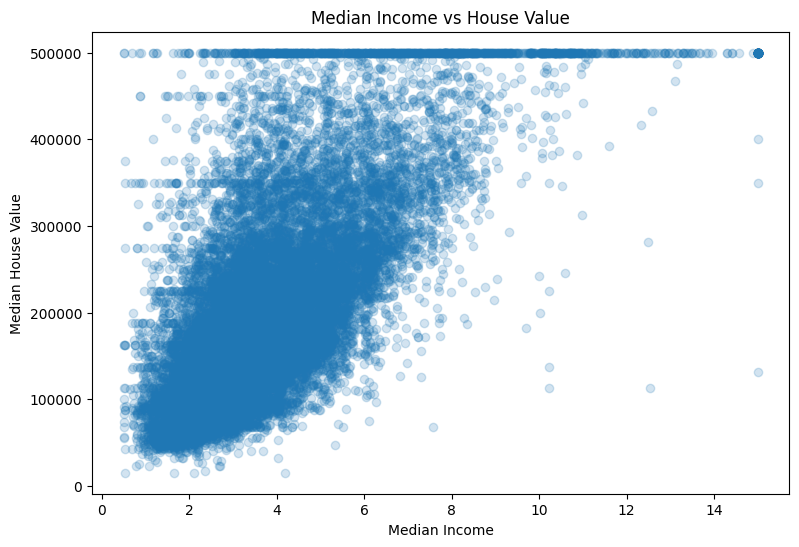

In [18]:
plt.figure(figsize=(9,6))
plt.scatter(data["median_income"], data["median_house_value"], alpha=0.2)
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Median Income vs House Value")
plt.show()

**Observaciones:**
- El límite superior son $500000
- relación casi lineal

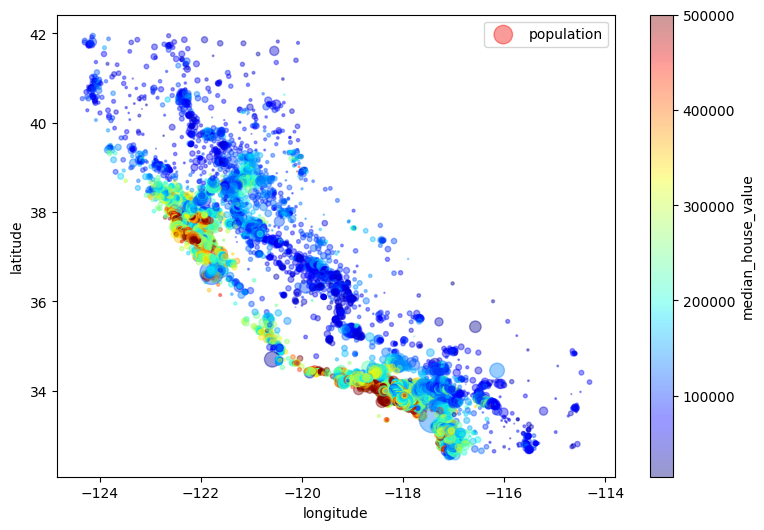

In [19]:
data.plot(
    kind="scatter",
    x="longitude",
    y="latitude",
    alpha=0.4,
    s=data["population"]/100,
    label="population",
    figsize=(9,6),
    c="median_house_value",
    cmap="jet",
    colorbar=True
)

plt.legend()
plt.show()

**Observaciones:**

Los precios más altos se concentran en:
zonas costeras
- área de Los Ángeles
- área de San Francisco

Existe una relación geográfica fuerte entre ubicación y precio.

## 5. Preparación de datos para Machine Learning

In [20]:
# Separar variables predictoras (x) y variable objetivo (y)
x = data.drop("median_house_value", axis=1)
y = data["median_house_value"]

In [21]:
# Codificar variable categórica 
# ocean_proximity no puede ir directo al modelo. 
x = pd.get_dummies(x, columns=["ocean_proximity"])

In [ ]:
# comprobación de las columnas después de su creación
x.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'bedrooms_per_room', 'rooms_per_household', 'population_per_household',
       'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'],
      dtype='str')

In [36]:
# Train / Test split
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

feature_names = x.columns

## 6. Modelos Predictivos

In [ ]:
# comprobación de que nohaya valores nulos después de la creación de las nuevas columnas
data.isnull().sum()

longitude                   0
latitude                    0
housing_median_age          0
total_rooms                 0
total_bedrooms              0
population                  0
households                  0
median_income               0
median_house_value          0
ocean_proximity             0
bedrooms_per_room           0
rooms_per_household         0
population_per_household    0
dtype: int64

In [49]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median") #por si truena por valores nulos en el futuro, aunque ya los hya tratado

# Ajustar en train
# fit_transform() convierte el DataFrame en un numpy array
#x_train = imputer.fit_transform(x_train)

# Aplicar al test
#x_test = imputer.transform(x_test)

x_train = pd.DataFrame(
    imputer.fit_transform(x_train),
    columns=feature_names
)

x_test = pd.DataFrame(
    imputer.transform(x_test),
    columns=feature_names
)

### Modelo 1. Regresión Lineal

In [50]:
# Modelo 1. Regresión Lineal
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

lin_model = LinearRegression()

lin_model.fit(x_train, y_train)

pred_lin = lin_model.predict(x_test)

rmse_lin = np.sqrt(mean_squared_error(y_test, pred_lin))

#(Root Mean Squared Error)
print("RMSE Linear Regression:", rmse_lin)

RMSE Linear Regression: 72668.53837868226


### Modelo 2. Random Forest

In [51]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(x_train, y_train)

pred_rf = rf_model.predict(x_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))

#(Root Mean Squared Error)
print("RMSE Random Forest:", rmse_rf)

RMSE Random Forest: 50382.59359428678


# 7. Evaluación de modelos (métricas)

In [52]:
# Regresión Lineal
rmse_rl = np.sqrt(mean_squared_error(y_test, pred_lin))
mae_rl = mean_absolute_error(y_test, pred_lin)
r2_rl = r2_score(y_test, pred_lin)
print(">>> REGRESSION LINEAL <<<")
print("RMSE:", rmse_rl)
print("MAE:", mae_rl)
print("R2:", r2_rl)

>>> REGRESSION LINEAL <<<
RMSE: 72668.53837868226
MAE: 50888.660015720285
R2: 0.5970176824350761


In [53]:
# Random Forest
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
mae_rf = mean_absolute_error(y_test, pred_rf)
r2_rf = r2_score(y_test, pred_rf)
print(">>> RANDOM FOREST REGRESSOR <<<")
# Root Mean Squared Error
# Mean Absolute Error
# R-squared Coeficiente de determinación
print("RMSE:", rmse_rf)
print("MAE:", mae_rf)
print("R2:", r2_rf)

>>> RANDOM FOREST REGRESSOR <<<
RMSE: 50382.59359428678
MAE: 32358.5794500969
R2: 0.8062890456768209


| Modelo           | RMSE   | MAE    | R²    |
| ---------------- | ------ | ------ | ----- |
| Regresión Lineal | 72,668 | 50,888 | 0.597 |
| Random Forest    | 50,382 | 32,358 | 0.806 |


> **Interpretación**

**RMSE (Root Mean Squared Error)**
- Regresión Lineal: ≈ 72,668
- Random Forest: ≈ 50,382

Esto significa que el Random Forest reduce el error en ~22,000 dólares por predicción.

--

**MAE (Mean Absolute Error)**
- Regresión Lineal: ≈ 50,888
- Random Forest: ≈ 32,358

En promedio:
Regresión lineal se equivoca ~50 mil dólares
Random Forest ~32 mil dólares

Otra vez Random Forest gana claramente.

--

**R² (Coeficiente de determinación)**
- Regresión Lineal: 0.59
- Random Forest: 0.81

Regresión Lineal explica 59% de la variabilidad del precio

Random Forest explica 81% de la variabilidad

Esto es una mejora muy fuerte.


**Conclusión técnica**

>Se evaluaron dos modelos de predicción: Regresión Lineal y Random Forest.
El modelo Random Forest presentó un mejor desempeño en todas las métricas de evaluación.
Obtuvo un RMSE de 50,382 frente a 72,668 de la regresión lineal, lo que indica una reducción significativa en el error de predicción.
Además, el coeficiente R² de 0.806 indica que el modelo explica aproximadamente el 81% de la variabilidad del valor de las viviendas.
Por lo tanto, Random Forest se selecciona como el modelo final para la predicción del precio de las viviendas.

## 8. Cross Validation

In [54]:
from sklearn.model_selection import cross_val_score
import numpy as np

scores = cross_val_score(
    rf_model,
    x_train,
    y_train,
    scoring="neg_mean_squared_error",
    cv=5
)

rmse_scores = np.sqrt(-scores)

print("RMSE por fold:", rmse_scores)
print("RMSE promedio:", rmse_scores.mean())
print("Desviación estándar:", rmse_scores.std())

RMSE por fold: [49683.29519869 51424.77104367 50477.97091068 49522.1605542
 50229.44878172]
RMSE promedio: 50267.52929779009
Desviación estándar: 675.5513752506483


# 9. Feature Importance
 

In [55]:
feature_importances = pd.Series(
    rf_model.feature_importances_,
    index=feature_names
)

feature_importances = feature_importances.sort_values(ascending=False)

print(feature_importances)

median_income                 0.481547
ocean_proximity_INLAND        0.137504
population_per_household      0.121577
longitude                     0.057757
latitude                      0.056305
housing_median_age            0.044244
rooms_per_household           0.025774
bedrooms_per_room             0.024260
total_rooms                   0.012691
total_bedrooms                0.012131
population                    0.011684
households                    0.010187
ocean_proximity_NEAR OCEAN    0.002185
ocean_proximity_<1H OCEAN     0.001218
ocean_proximity_NEAR BAY      0.000806
ocean_proximity_ISLAND        0.000129
dtype: float64


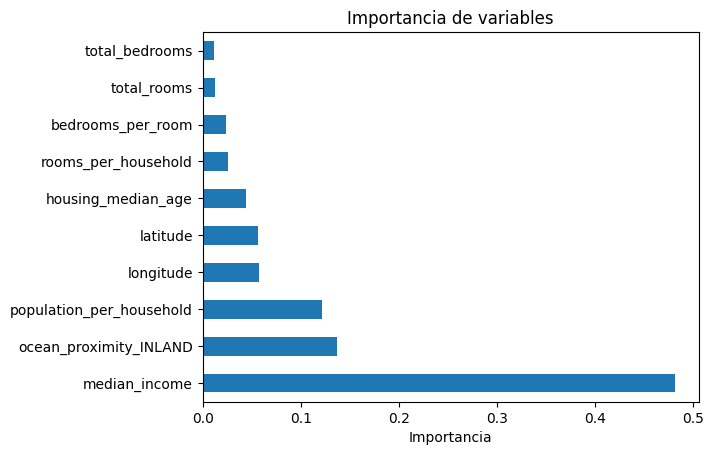

In [56]:
feature_importances.head(10).plot(kind="barh")
plt.title("Importancia de variables")
plt.xlabel("Importancia")
plt.show()